In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('AB_NYC_2019.csv')

df.shape
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [5]:
# Check price == 0 listings
print(df[df['price'] == 0].shape)

# Check your hypothesis about the missing reviews data
print(df[df['reviews_per_month'].isna()]['number_of_reviews'].describe())

(11, 16)
count    10052.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: number_of_reviews, dtype: float64


In [6]:
df = df[df['price'] > 0].copy()
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')

print(df.shape)
print(df.isna().sum())


(48884, 16)
id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10051
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


0.900     269.0
0.950     355.0
0.990     799.0
0.999    3000.0
Name: price, dtype: float64
14


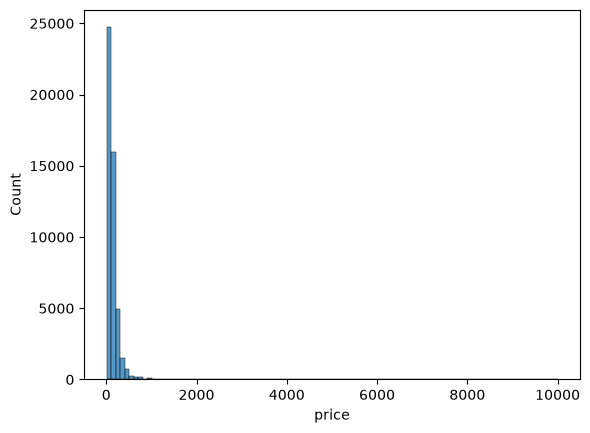

In [7]:
print(df['price'].quantile([0.90, 0.95, 0.99, 0.999]))
print((df['minimum_nights'] > 365).sum())
sns.histplot(df['price'], bins=100)
plt.show()

(48631, 16)


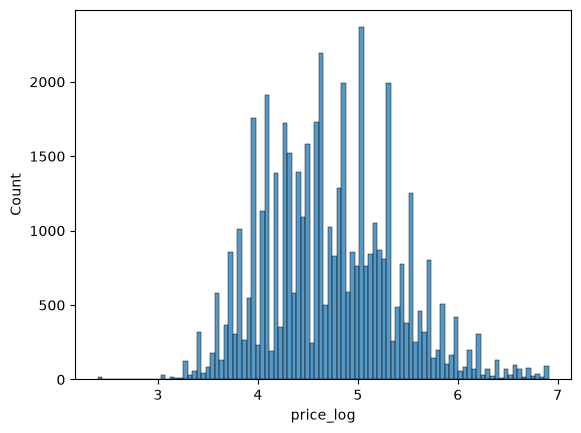

In [8]:
# Drop the minimum_nights outliers (14 rows)
df = df[df['minimum_nights'] <= 365].copy()

# Drop extreme price outliers
df = df[df['price'] <= 1000].copy()

print(df.shape)

# Log-transform price — this becomes our actual modeling target
df['price_log'] = np.log1p(df['price'])   # log1p = log(1 + x), safe even if price were 0

sns.histplot(df['price_log'], bins=100)
plt.show()

In [9]:
for col in ['neighbourhood_group', 'neighbourhood', 'room_type']:
    print(col, '->', df[col].nunique())
    
print(df['neighbourhood_group'].value_counts())
print(df['room_type'].value_counts())

neighbourhood_group -> 5
neighbourhood -> 221
room_type -> 3
neighbourhood_group
Manhattan        21482
Brooklyn         20035
Queens            5654
Bronx             1089
Staten Island      371
Name: count, dtype: int64
room_type
Entire home/apt    25207
Private room       22269
Shared room         1155
Name: count, dtype: int64


In [10]:
# One-hot encode small categorical columns
df = pd.get_dummies(df, columns=['neighbourhood_group', 'room_type'], drop_first=True)

# Frequency-encode neighbourhood (221 unique values)
neighbourhood_freq = df['neighbourhood'].value_counts()
df['neighbourhood_freq'] = df['neighbourhood'].map(neighbourhood_freq)
df = df.drop(columns=['neighbourhood'])

# Drop pure identifiers and raw text columns we're not using
df = df.drop(columns=['id', 'host_id', 'name', 'host_name'])

print(df.shape)
print(df.columns.tolist())

(48631, 17)
['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'price_log', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_freq']


In [11]:
df['last_review'] = pd.to_datetime(df['last_review'])
reference_date = df['last_review'].max()  # most recent review date in the dataset = our "today"

df['days_since_last_review'] = (reference_date - df['last_review']).dt.days
max_days = df['days_since_last_review'].max()
df['days_since_last_review'] = df['days_since_last_review'].fillna(max_days + 1)

df['never_reviewed'] = (df['number_of_reviews'] == 0).astype(int)

df = df.drop(columns=['last_review'])

In [12]:
# Rough Manhattan/Times Square center point
center_lat, center_lon = 40.7580, -73.9855
df['distance_to_center'] = np.sqrt((df['latitude'] - center_lat)**2 + (df['longitude'] - center_lon)**2)

In [13]:
print(df[['days_since_last_review', 'never_reviewed', 'distance_to_center']].describe())
print(df.isna().sum())
print(df.shape)

       days_since_last_review  never_reviewed  distance_to_center
count            48631.000000    48631.000000        48631.000000
mean               836.577533        0.203800            0.070597
std               1167.063790        0.402826            0.045711
min                  0.000000        0.000000            0.000677
25%                 19.000000        0.000000            0.037221
50%                185.000000        0.000000            0.065418
75%               1184.000000        0.000000            0.091831
max               3025.000000        1.000000            0.363140
latitude                             0
longitude                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
reviews_per_month                    0
calculated_host_listings_count       0
availability_365                     0
price_log                            0
neighbourhood_group_Brooklyn         0
neighbourhood_gr

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['price', 'price_log'])
y = df['price_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)
print(X.columns.tolist())

(38904, 17) (9727, 17)
['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_freq', 'days_since_last_review', 'never_reviewed', 'distance_to_center']


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)

# Predictions in log-space
y_pred_log = pipeline.predict(X_test)

# Metrics in log-space
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
r2 = r2_score(y_test, y_pred_log)

# Convert back to real dollars for interpretability
y_test_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_pred_log)
rmse_dollars = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
mae_dollars = mean_absolute_error(y_test_dollars, y_pred_dollars)

print(f"Log-space  -> RMSE: {rmse_log:.4f}, MAE: {mae_log:.4f}, R2: {r2:.4f}")
print(f"Dollar-space -> RMSE: ${rmse_dollars:.2f}, MAE: ${mae_dollars:.2f}")

Log-space  -> RMSE: 0.4342, MAE: 0.3292, R2: 0.5607
Dollar-space -> RMSE: $90.82, MAE: $48.82


In [17]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),   # not strictly needed for trees, but keeps pipeline consistent
    ('model', RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)

# Evaluate on both sets
for name, X_set, y_set in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
    y_pred = rf_pipeline.predict(X_set)
    rmse = np.sqrt(mean_squared_error(y_set, y_pred))
    mae = mean_absolute_error(y_set, y_pred)
    r2 = r2_score(y_set, y_pred)
    print(f"{name} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

Train -> RMSE: 0.2741, MAE: 0.2083, R2: 0.8294
Test -> RMSE: 0.3893, MAE: 0.2897, R2: 0.6469


In [18]:
from sklearn.ensemble import GradientBoostingRegressor

gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42))
])

gb_pipeline.fit(X_train, y_train)

for name, X_set, y_set in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
    y_pred = gb_pipeline.predict(X_set)
    rmse = np.sqrt(mean_squared_error(y_set, y_pred))
    mae = mean_absolute_error(y_set, y_pred)
    r2 = r2_score(y_set, y_pred)
    print(f"{name} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

Train -> RMSE: 0.3899, MAE: 0.2913, R2: 0.6548
Test -> RMSE: 0.3927, MAE: 0.2932, R2: 0.6407


In [19]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 8, 10, 12, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__max_features': ['sqrt', 'log2', 0.5]
}

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV R2:", random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 15}
Best CV R2: 0.6323525232748335


In [20]:
best_rf_pipeline = random_search.best_estimator_

for name, X_set, y_set in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
    y_pred = best_rf_pipeline.predict(X_set)
    rmse = np.sqrt(mean_squared_error(y_set, y_pred))
    mae = mean_absolute_error(y_set, y_pred)
    r2 = r2_score(y_set, y_pred)
    print(f"{name} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

Train -> RMSE: 0.3129, MAE: 0.2317, R2: 0.7777
Test -> RMSE: 0.3866, MAE: 0.2875, R2: 0.6517


In [21]:
import joblib

# Final dollar-space metrics for your report
y_pred_log_final = best_rf_pipeline.predict(X_test)
y_pred_dollars_final = np.expm1(y_pred_log_final)
y_test_dollars_final = np.expm1(y_test)
mae_dollars_final = mean_absolute_error(y_test_dollars_final, y_pred_dollars_final)
rmse_dollars_final = np.sqrt(mean_squared_error(y_test_dollars_final, y_pred_dollars_final))
print(f"Final model dollar-space -> RMSE: ${rmse_dollars_final:.2f}, MAE: ${mae_dollars_final:.2f}")

# Save the full pipeline (scaler + model together)
joblib.dump(best_rf_pipeline, 'airbnb_price_pipeline.pkl')

# Also save the neighbourhood frequency mapping — you'll need this
# to transform a NEW neighbourhood name typed into the Streamlit app
joblib.dump(neighbourhood_freq, 'neighbourhood_freq_map.pkl')

print("Saved successfully")

Final model dollar-space -> RMSE: $82.69, MAE: $43.57
Saved successfully


In [23]:
df_raw = pd.read_csv('AB_NYC_2019.csv')
neighbourhood_coords = df_raw.groupby('neighbourhood')[['latitude', 'longitude']].mean()

joblib.dump(neighbourhood_coords, 'neighbourhood_coords_map.pkl')
print(neighbourhood_coords.head())

                latitude  longitude
neighbourhood                      
Allerton       40.865292 -73.858727
Arden Heights  40.552410 -74.182253
Arrochar       40.593900 -74.074600
Arverne        40.591853 -73.794839
Astoria        40.764299 -73.920002
